<a href="https://colab.research.google.com/github/RushanMohiuddin123/Language-Translator/blob/main/Copy_of_E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Products.csv to Products.csv


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Order Items.csv to Order Items.csv


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Orders.csv to Orders.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Customers.csv to Customers.csv


In [ ]:
import pandas as pd

Orders = pd.read_csv("Orders.csv")
customers = pd.read_csv("Customers.csv")
products = pd.read_csv("Products.csv")
order_items = pd.read_csv("Order Items.csv")

Orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00


In [ ]:
# Convert date column
Orders['order_purchase_timestamp'] = pd.to_datetime(
    Orders['order_purchase_timestamp']
)

# Remove duplicates
Orders.drop_duplicates(inplace=True)

# Fill missing values
Orders.fillna(method='ffill', inplace=True)

Orders.info()

/tmp/ipykernel_561/1970209211.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Orders.fillna(method='ffill', inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  object        
 5   order_delivered_carrier_date   99441 non-null  object        
 6   order_delivered_customer_date  99441 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [ ]:
df = Orders.merge(customers, on='customer_id') \
           .merge(order_items, on='order_id') \
           .merge(products, on='product_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [ ]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")
df.to_sql("ecommerce", conn, if_exists="replace", index=False)

112650

In [ ]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

revenue = df.groupby('month')['price'].sum()
revenue


,price
month,
2016-09,267.36
2016-10,49507.66
2016-12,10.90
2017-01,120312.87
2017-02,247303.02
2017-03,374344.30
2017-04,359927.23
2017-05,506071.14
2017-06,433038.60


In [ ]:
top_customers = df.groupby('customer_id')['price'].sum() \
                  .sort_values(ascending=False).head(10)

top_customers

,price
customer_id,
1617b1357756262bfa56ab541c47bc16,13440.0
ec5b2ba62e574342386871631fafd3fc,7160.0
c6e2731c5b391845f6800c97401a43a9,6735.0
f48d464a0baaea338cb25f816991ab1f,6729.0
3fd6777bbce08a352fddd04e4a7cc8f6,6499.0
05455dfa7cd02f13d132aa7a6a9729c6,5934.6
df55c14d1476a9a3467f131269c2477f,4799.0
24bbf5fd2f2e1b359ee7de94defc4a15,4690.0
e0a2412720e9ea4f26c1ac985f6a7358,4599.9


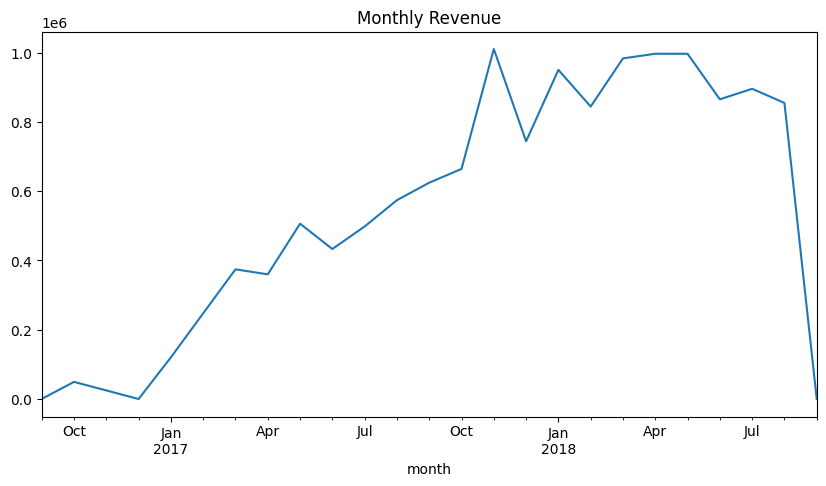

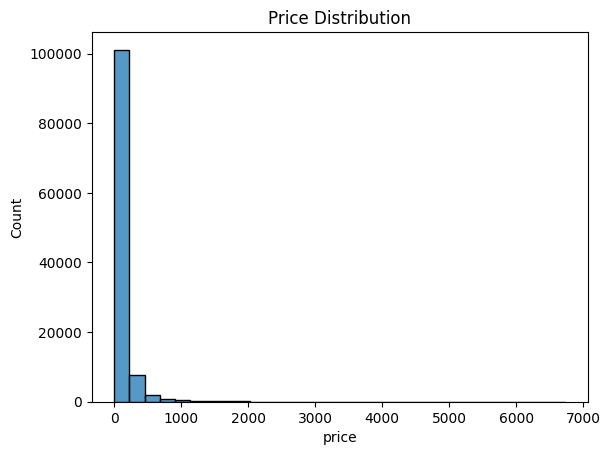

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revenue trend
revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue")
plt.show()

# Distribution
sns.histplot(df['price'], bins=30)
plt.title("Price Distribution")
plt.show()

In [ ]:
import datetime as dt

snapshot_date = df['order_purchase_timestamp'].max()

rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'price': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,292,1,89.80
000161a058600d5901f007fab4c27140,413,1,54.90
0001fd6190edaaf884bcaf3d49edf079,551,1,179.99
0002414f95344307404f0ace7a26f1d5,382,1,149.90
000379cdec625522490c315e70c7a9fb,153,1,93.00


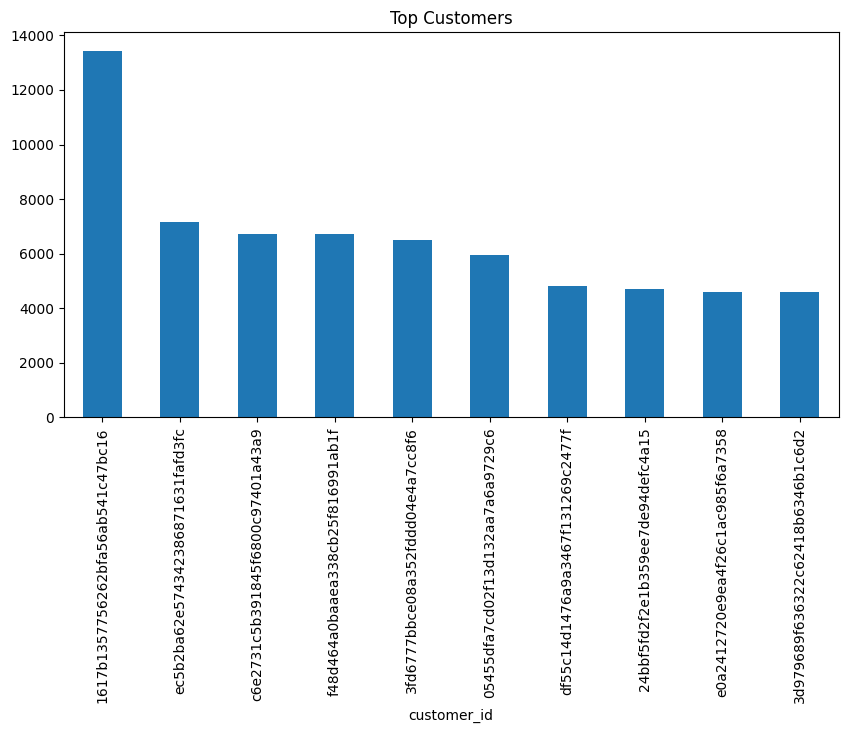

In [ ]:
import matplotlib.pyplot as plt

top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top Customers")
plt.show()